# Лабораторная работа 7 #

## Выполнила: Иванова Дарья Сергеевна БПМ-23-ПО-2 

Задача: В рамках задания необходимо построить модель машинного обучения для классификации электронных писем на два класса: обычные письма и фишинговые письма. В качестве исходных данных используется датасет email_phishing_data.csv, содержащий числовые характеристики писем: количество слов, уникальных слов, стоп-слов, ссылок, уникальных доменов, email-адресов, орфографических ошибок и срочных ключевых слов.

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Загружаю данные

In [2]:
df = pd.read_csv('email_phishing_data.csv')
df.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


Разделение на признаки и целевую переменную

In [3]:
X = df.drop('label', axis=1)
y = df['label']

Feature Engineering

In [ ]:
def create_features(X):
    X = X.copy()
    
    X['uniq_ratio'] = X['num_unique_words'] / (X['num_words'] + 1)
    X['stop_ratio'] = X['num_stopwords'] / (X['num_words'] + 1)
    X['link_ratio'] = X['num_links'] / (X['num_words'] + 1)
    X['domain_ratio'] = X['num_unique_domains'] / (X['num_links'] + 1)
    X['email_ratio'] = X['num_email_addresses'] / (X['num_words'] + 1)
    X['error_ratio'] = X['num_spelling_errors'] / (X['num_words'] + 1)
    X['urgent_ratio'] = X['num_urgent_keywords'] / (X['num_words'] + 1)
    
    return X

Очистка данных

In [12]:
def clean_data(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    return X

Pipeline

In [13]:
pipe = Pipeline([
    ('features', FunctionTransformer(create_features)),
    ('clean', FunctionTransformer(clean_data)),
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

Разделение данных

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Обучение модели

In [15]:
pipe.fit(X_train, y_train)

,steps,"[('features', ...), ('clean', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cre...002B8BEFFFE20>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


Оценка качества

In [17]:
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.9875510865112557
Test Accuracy: 0.9873011336572354

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    103573
           1       0.78      0.06      0.12      1397

    accuracy                           0.99    104970
   macro avg       0.88      0.53      0.56    104970
weighted avg       0.98      0.99      0.98    104970

Matrix:

[[103548     25]
 [  1308     89]]


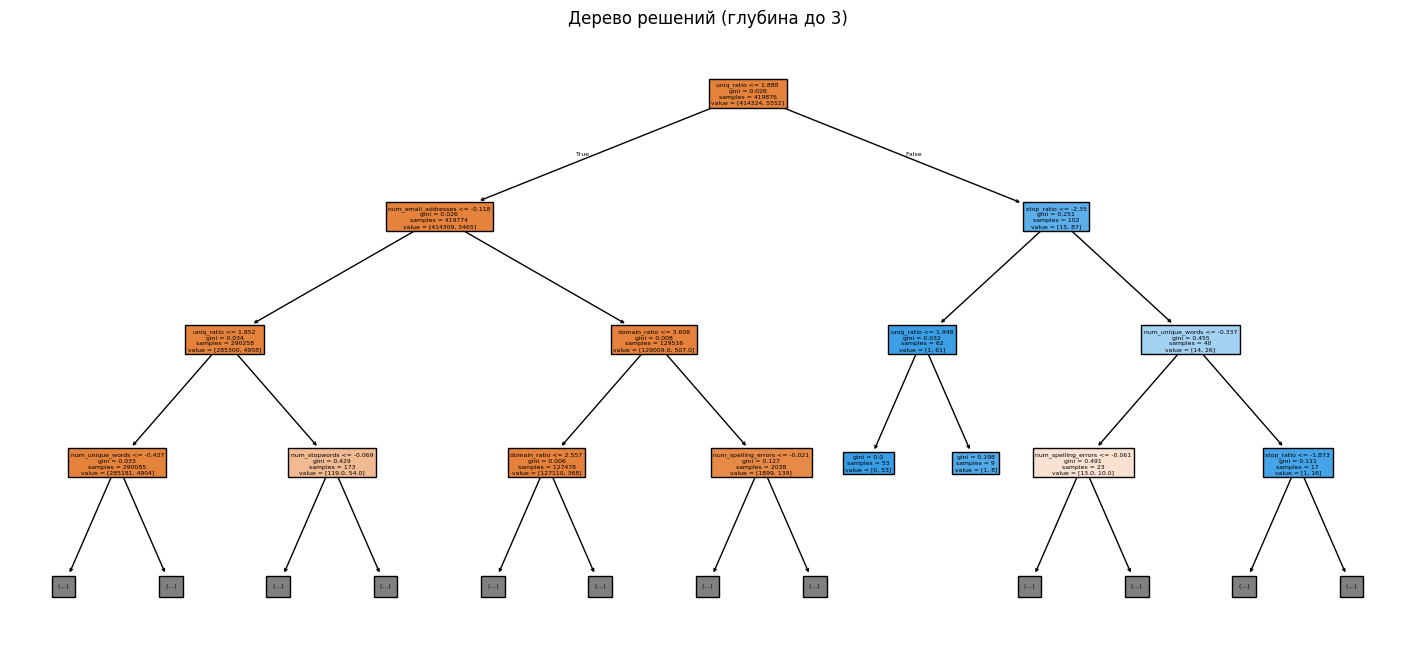

In [27]:
feature_names = list(X.columns) + [
    'uniq_ratio', 'stop_ratio', 'link_ratio',
    'domain_ratio', 'email_ratio', 'error_ratio', 'urgent_ratio'
]

plt.figure(figsize=(18,8))

plot_tree(
    pipe.named_steps['model'],
    feature_names=feature_names,
    filled=True,
    max_depth=3
)

plt.title("Дерево решений (глубина до 3)")
plt.show()

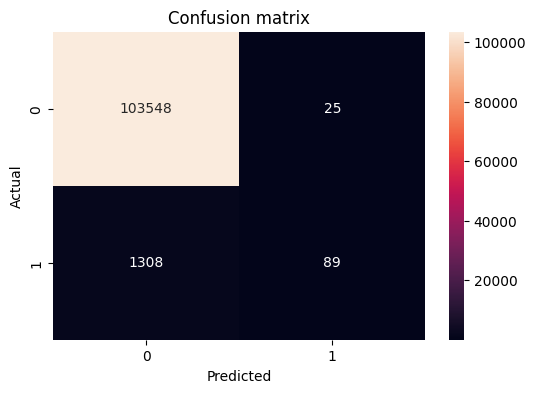

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")

plt.show()

**Вывод**: точность на обучающей выборке получилась 0.9876, на тестовой выборке 0.9873